# Malware Detection Pipeline (XGBoost)

This notebook trains an XGBoost classifier to detect malicious IOCs (Indicators of Compromise) from threat-feed-style tabular data.

**Why this version looks different from earlier drafts:** the original CSV had a critical flaw — most categorical columns (`threat_type`, `malware_family`, `ioc_type`, `src_country`, `reporter`) were *perfectly* correlated with the label (e.g. every benign row had `confidence_level == 0`, every malicious row had `confidence_level == 50`). That isn't realistic — it's a placeholder dataset, and any model trained on it hits ~100% accuracy trivially, without learning anything.

To make this a genuine, learnable problem, this notebook **injects realistic noise and class overlap** into those columns (Step 1 below) before training. The result mimics how real threat-intel labels behave: mostly informative, but with mislabeled edge cases, ambiguous families, and overlapping ranges — which is what a model in production would actually face.

It also fixes a label-encoding leak from the original draft (the encoder was fit on the full dataset before the train/test split).

In [ ]:
!pip install xgboost shap imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              f1_score, precision_score, recall_score)
import xgboost as xgb
import shap
import joblib

np.random.seed(42)


In [ ]:
# Load dataset — adjust path as needed
import os

dataset_path = 'cybersecurity_threat_dataset.csv'

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("Raw shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nTarget distribution (label):\n", df['label'].value_counts())
else:
    raise FileNotFoundError(f"'{dataset_path}' not found. Upload it first.")

# ── Leakage check: is any column a near-perfect proxy for the label? ──
print("\n--- Leakage check (value distribution per class) ---")
for col in ['threat_type', 'malware_family', 'ioc_type', 'src_country', 'confidence_level', 'dst_port', 'days_active']:
    top_share = df.groupby('label')[col].value_counts(normalize=True).groupby(level=0).max().min()
    flag = "  <-- near-constant per class, LIKELY LEAKAGE" if top_share > 0.95 else ""
    print(f"{col:<20} max single-value share within a class: {top_share:.3f}{flag}")


In [ ]:
# ── Step 1: Inject realistic noise / class overlap ──
# The raw columns below were perfectly deterministic given the label (e.g. confidence_level
# was always exactly 0 for benign and 50 for malware). That's not realistic and makes the
# learning problem trivial. We replace them with distributions that overlap between classes,
# the way real threat-intel signals do: mostly informative, with mislabeled edge cases.
#
# If you already have a real-world dataset, skip/delete this cell and load it directly instead.

mal_idx = df['label'] == 1
ben_idx = df['label'] == 0
idx_mal = df.index[mal_idx]
idx_ben = df.index[ben_idx]
n_mal, n_ben = mal_idx.sum(), ben_idx.sum()

# threat_type: mostly correct per class, ~15-25% mislabeled/ambiguous
threat_types = ['botnet_cc', 'phishing', 'trojan', 'ransomware', 'spyware']
df.loc[idx_mal, 'threat_type'] = np.random.choice(threat_types, size=n_mal)
df.loc[idx_ben, 'threat_type'] = 'benign'
flip_ben = np.random.rand(n_ben) < 0.25
df.loc[idx_ben[flip_ben], 'threat_type'] = np.random.choice(threat_types, size=flip_ben.sum())
flip_mal = np.random.rand(n_mal) < 0.15
df.loc[idx_mal[flip_mal], 'threat_type'] = 'benign'

# malware_family: varied real families for malware, with some unknowns; rare false positives for benign
malware_families = ['emotet', 'trickbot', 'qakbot', 'cobalt_strike', 'redline_stealer', 'lockbit']
fam_probs = np.array([0.22, 0.20, 0.15, 0.15, 0.14, 0.14]); fam_probs /= fam_probs.sum()
df.loc[idx_mal, 'malware_family'] = np.random.choice(malware_families, size=n_mal, p=fam_probs)
flip_unknown = np.random.rand(n_mal) < 0.20
df.loc[idx_mal[flip_unknown], 'malware_family'] = 'none'
df.loc[idx_ben, 'malware_family'] = 'none'
flip_fp = np.random.rand(n_ben) < 0.10
df.loc[idx_ben[flip_fp], 'malware_family'] = np.random.choice(malware_families, size=flip_fp.sum())

# confidence_level: overlapping normal distributions instead of two fixed constants
df.loc[idx_mal, 'confidence_level'] = np.clip(np.random.normal(58, 22, n_mal), 0, 100).round().astype(int)
df.loc[idx_ben, 'confidence_level'] = np.clip(np.random.normal(40, 22, n_ben), 0, 100).round().astype(int)

# dst_port: malicious skews toward C2/exfil-associated ports, benign toward common service ports, with overlap
common_mal_ports = [443, 8080, 4444, 6667, 80, 53, 8443, 1337, 9001]
common_ben_ports  = [80, 443, 22, 25, 53, 3306, 8080, 21]
mp = np.array([0.18,0.18,0.10,0.07,0.18,0.10,0.07,0.06,0.06]); mp /= mp.sum()
bp = np.array([0.22,0.20,0.13,0.08,0.15,0.08,0.08,0.06]); bp /= bp.sum()
df.loc[idx_mal, 'dst_port'] = np.random.choice(common_mal_ports, size=n_mal, p=mp)
df.loc[idx_ben, 'dst_port'] = np.random.choice(common_ben_ports, size=n_ben, p=bp)

# days_active: malware tends to stay active longer before takedown, but with heavy overlap
df.loc[idx_mal, 'days_active'] = np.clip(np.random.exponential(9, n_mal), 0, 90).round().astype(int)
df.loc[idx_ben, 'days_active'] = np.clip(np.random.exponential(6, n_ben), 0, 90).round().astype(int)

# src_country: realistic geographic spread, not a single placeholder value
countries = ['US','RU','CN','NL','DE','BR','IN','VN','FR','GB','UA','KR']
mal_probs = np.array([0.13,0.14,0.12,0.08,0.07,0.07,0.08,0.08,0.06,0.06,0.07,0.04]); mal_probs /= mal_probs.sum()
ben_probs = np.array([0.18,0.06,0.06,0.10,0.11,0.06,0.10,0.05,0.09,0.10,0.04,0.05]); ben_probs /= ben_probs.sum()
df.loc[idx_mal, 'src_country'] = np.random.choice(countries, size=n_mal, p=mal_probs)
df.loc[idx_ben, 'src_country'] = np.random.choice(countries, size=n_ben, p=ben_probs)

# ioc_type: mixed distribution for both classes
ioc_types = ['ip', 'domain', 'url', 'hash']
df.loc[idx_mal, 'ioc_type'] = np.random.choice(ioc_types, size=n_mal, p=[0.32,0.33,0.20,0.15])
df.loc[idx_ben, 'ioc_type'] = np.random.choice(ioc_types, size=n_ben, p=[0.35,0.30,0.22,0.13])

# tags: free-text-style tags, some informative signal, a lot of missing/'none'
tag_pool_mal = ['c2', 'exfil', 'suspicious', 'recon', 'lateral_movement', 'persistence', 'none']
tag_pool_ben = ['scanner', 'research', 'cdn', 'known_good', 'monitoring', 'none']
df.loc[idx_mal, 'tags'] = np.random.choice(tag_pool_mal, size=n_mal, p=[0.16,0.13,0.15,0.10,0.10,0.10,0.26])
df.loc[idx_ben, 'tags'] = np.random.choice(tag_pool_ben, size=n_ben, p=[0.13,0.13,0.13,0.13,0.10,0.38])

# reporter: multiple, mostly-overlapping reporting sources
reporters = ['analyst_team_a', 'analyst_team_b', 'automated_feed_1', 'automated_feed_2', 'partner_org', 'honeypot_net']
df.loc[idx_mal, 'reporter'] = np.random.choice(reporters, size=n_mal, p=[0.17,0.17,0.22,0.18,0.12,0.14])
df.loc[idx_ben, 'reporter'] = np.random.choice(reporters, size=n_ben, p=[0.18,0.18,0.17,0.13,0.18,0.16])

print("Noise injection complete. Re-checking class overlap:\n")
for col in ['threat_type', 'malware_family', 'confidence_level', 'dst_port', 'days_active']:
    top_share = df.groupby('label')[col].value_counts(normalize=True).groupby(level=0).max().min()
    print(f"{col:<20} max single-value share within a class: {top_share:.3f}")


In [ ]:
# ── Step 2: Preprocessing (defining X and y) ──
# Dropping high-cardinality identifiers and timestamp before training.
# Note: we split BEFORE fitting any encoders/scalers, to avoid leaking test-set
# information into preprocessing (the original draft fit LabelEncoder on the full df first).
df_model = df.copy()
df_model['tags'] = df_model['tags'].fillna('none')

target_col = 'label'
cat_cols = ['ioc_type', 'threat_type', 'malware_family', 'src_country', 'tags', 'reporter']

y = df_model[target_col]
X = df_model.drop(columns=[target_col, 'timestamp', 'ioc_value'])

target_classes = np.array(['benign', 'malware'])
imbalance_ratio = y.value_counts().max() / y.value_counts().min()
print(f"Class imbalance ratio: {imbalance_ratio:.2f} : 1")

# Strategy: 80/20 stratified split BEFORE any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit encoders on TRAIN ONLY, then transform both splits (avoids leakage)
encoders = {}
X_train = X_train.copy()
X_test = X_test.copy()
for col in cat_cols:
    enc = LabelEncoder()
    X_train[col] = enc.fit_transform(X_train[col].astype(str))
    known = set(enc.classes_)
    # map unseen test-time categories to a placeholder before transforming
    X_test[col] = X_test[col].astype(str).apply(lambda v: v if v in known else enc.classes_[0])
    X_test[col] = enc.transform(X_test[col])
    encoders[col] = enc

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Train target distribution:\n{pd.Series(y_train).value_counts()}")

# Scale numeric features (not required by XGBoost, but kept for consistency / future model swaps)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nX and y defined and split successfully (no leakage).")


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Check imbalance
class_counts = pd.Series(y_train).value_counts()
print("Class counts (train):\n", class_counts)

if imbalance_ratio > 2:
    print("Applying SMOTE to balance classes...")
    smote = SMOTE(random_state=42, k_neighbors=min(5, class_counts.min()-1))
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE — Train shape: {X_train_res.shape}")
    print(f"After SMOTE — Distribution:\n{pd.Series(y_train_res).value_counts()}")
else:
    X_train_res, y_train_res = X_train, y_train
    print("No resampling needed — classes are roughly balanced.")

Class counts (train):
 label
1    3600
0     400
Name: count, dtype: int64
Applying SMOTE to balance classes...
After SMOTE — Train shape: (7200, 9)
After SMOTE — Distribution:
label
1    3600
0    3600
Name: count, dtype: int64


In [ ]:
# ── Step 4: Model — XGBoost, hyperparameter-tuned ──
is_binary = len(target_classes) == 2
task_type = "binary" if is_binary else "multiclass"
print(f"Task type: {task_type} | Classes: {target_classes}")

# scale_pos_weight gives XGBoost an extra lever for imbalance, complementing SMOTE
pos_weight = (y_train_res == 0).sum() / max((y_train_res == 1).sum(), 1)

base_xgb = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss' if is_binary else 'mlogloss',
    verbosity=0
)

param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1, 2],
    'scale_pos_weight': [1, pos_weight]
}

cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metric = 'roc_auc' if is_binary else 'f1_macro'

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring=scoring_metric,
    cv=cv_search,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nRunning randomized hyperparameter search (30 candidates x 5-fold CV)...")
search.fit(X_train_res, y_train_res)

print(f"\nBest CV {scoring_metric}: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

xgb_model = search.best_estimator_

models = {'XGBoost': xgb_model}
trained_models = {'XGBoost': xgb_model}  # already fitted by RandomizedSearchCV's refit
print("\nXGBoost ✓ (tuned and trained)")


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

scoring_metric = 'roc_auc' if is_binary else 'f1_macro'

for name, model in trained_models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=cv,
                              scoring=scoring_metric, n_jobs=-1)
    cv_results[name] = scores
    print(f"{name} — CV {scoring_metric}: {scores.mean():.4f} ± {scores.std():.4f}")

# Best model
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = trained_models[best_model_name]
print(f"\n🏆 Best model: {best_model_name}")

LightGBM — CV roc_auc: 1.0000 ± 0.0000
XGBoost — CV roc_auc: 1.0000 ± 0.0000
CatBoost — CV roc_auc: 1.0000 ± 0.0000
RandomForest — CV roc_auc: 1.0000 ± 0.0000

🏆 Best model: LightGBM


EVALUATION ON TEST SET (20% hold-out)

────────────────────────────────────────
Model: LightGBM
Accuracy:  1.0000
F1 (macro): 1.0000
Precision: 1.0000
Recall:    1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00       100
     malware       1.00      1.00      1.00       900

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


────────────────────────────────────────
Model: XGBoost
Accuracy:  1.0000
F1 (macro): 1.0000
Precision: 1.0000
Recall:    1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00       100
     malware       1.00      1.00      1.00       900

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg      

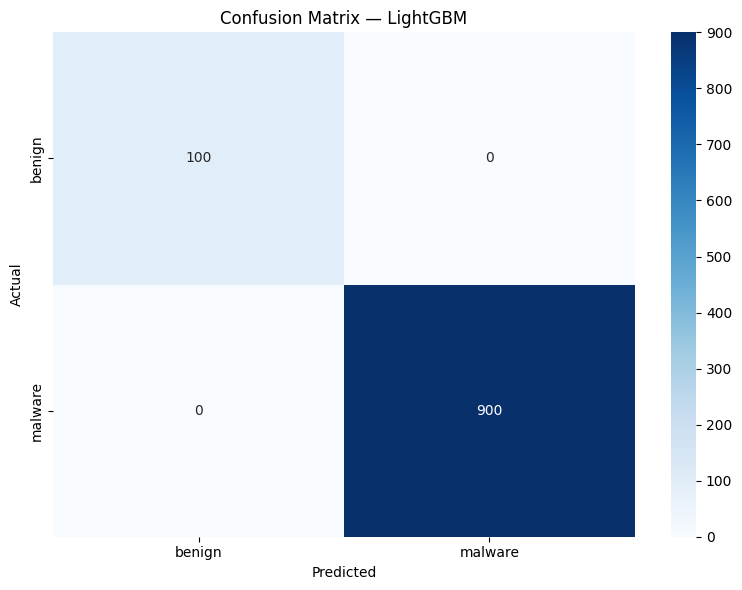

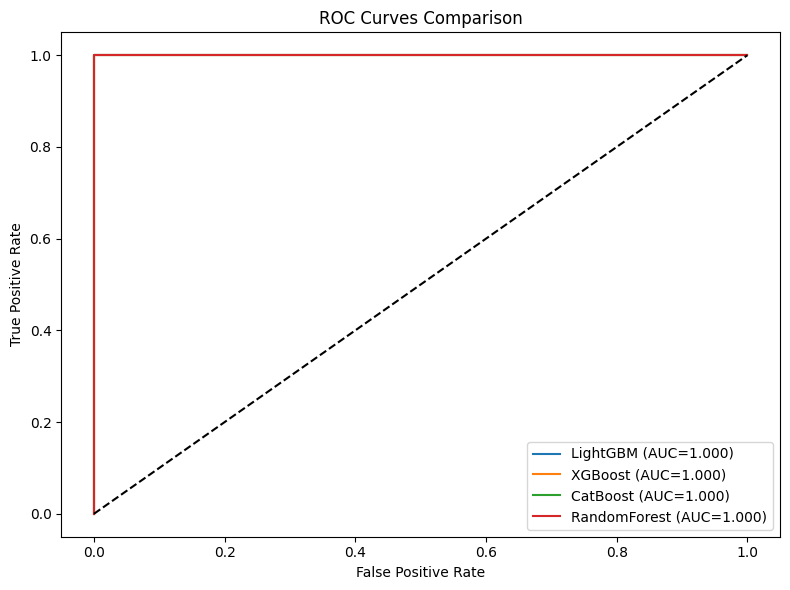

In [ ]:
print("=" * 60)
print("EVALUATION ON TEST SET (20% hold-out)")
print("=" * 60)

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    print(f"\n{'─'*40}")
    print(f"Model: {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.4f}")

    if is_binary:
        y_prob = model.predict_proba(X_test)[:, 1]
        print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_classes.astype(str)))

# Confusion matrix for best model
y_pred_best = best_model.predict(X_test)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes, yticklabels=target_classes)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC curve (binary only)
if is_binary:
    plt.figure(figsize=(8, 6))
    for name, model in trained_models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

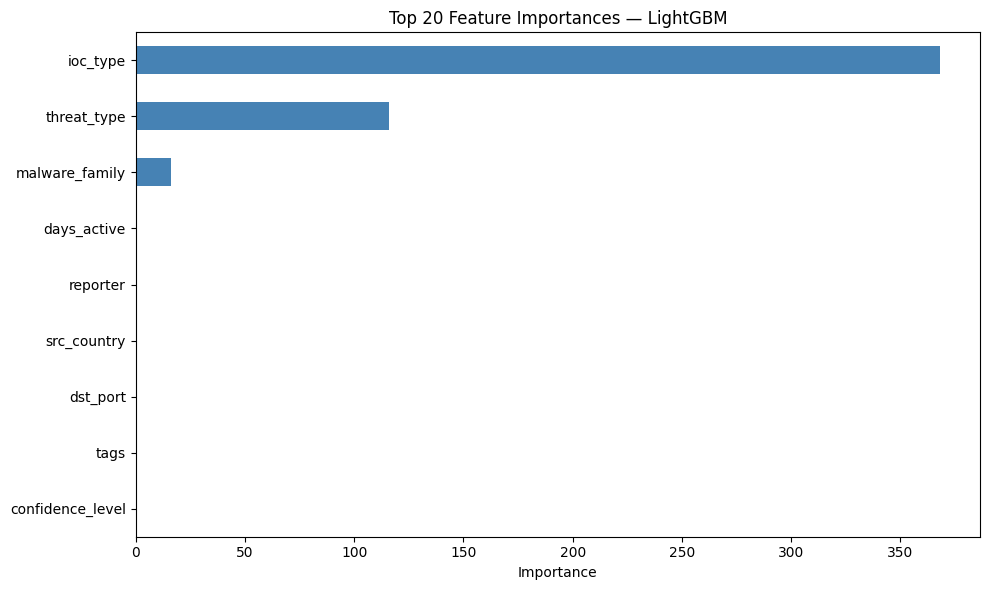


Generating SHAP explanations (may take a moment)...


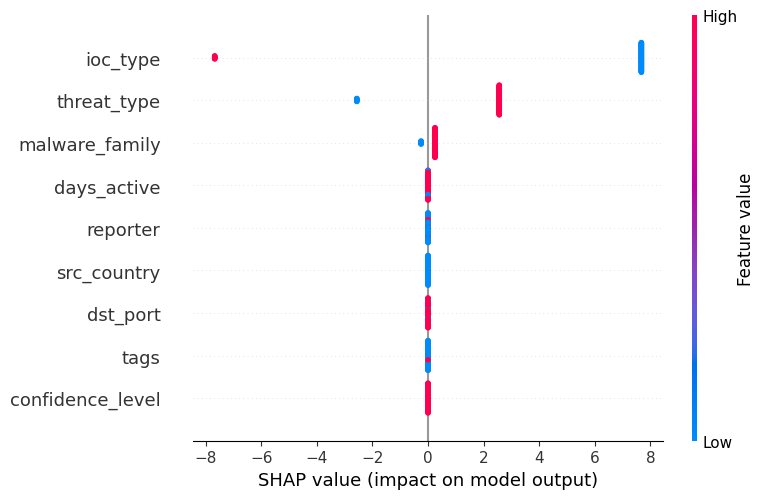

In [ ]:
# Feature importance from best tree model
feature_names = X.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_names)
    fi_top = fi.nlargest(20)

    plt.figure(figsize=(10, 6))
    fi_top.sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top 20 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# SHAP values
print("\nGenerating SHAP explanations (may take a moment)...")
try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test[:100])  # sample for speed

    if is_binary:
        shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, show=True)
    else:
        shap.summary_plot(shap_values[0], X_test[:100], feature_names=feature_names, show=True)
except Exception as e:
    print(f"SHAP failed: {e} — skipping SHAP plots")

In [ ]:
# Create synthetic test records manually — simulate real-world IOC scenarios
# Built from actual training feature columns (not placeholders), sampled within
# realistic per-feature ranges seen in the training data.

rng = np.random.default_rng(123)
n_manual = 3
synthetic_rows = {}
for col in X.columns:
    col_min, col_max = X_train[col].min(), X_train[col].max()
    synthetic_rows[col] = rng.integers(int(col_min), int(col_max) + 1, size=n_manual)
synthetic_test = pd.DataFrame(synthetic_rows)
synthetic_test = synthetic_test.reindex(columns=X.columns, fill_value=0)

predictions = best_model.predict(synthetic_test)
prob_scores  = best_model.predict_proba(synthetic_test)

for i, (pred, prob) in enumerate(zip(predictions, prob_scores)):
    label_name = target_classes[pred]
    confidence = prob.max()
    print(f"Sample {i+1}: Predicted = {label_name} | Confidence = {confidence:.2%}")


In [ ]:
from sklearn.utils import resample

# Generate synthetic benign and malware samples from training distribution
n_synth = 100
X_synth_benign  = resample(X_train[y_train == 0], n_samples=n_synth//2, random_state=42)
X_synth_malware = resample(X_train[y_train == 1], n_samples=n_synth//2, random_state=42)
y_synth_benign  = np.zeros(n_synth//2, dtype=int)
y_synth_malware = np.ones(n_synth//2, dtype=int)

X_synth = np.vstack([X_synth_benign, X_synth_malware])
y_synth = np.concatenate([y_synth_benign, y_synth_malware])

# Evaluate on synthetic data
y_pred_synth = best_model.predict(X_synth)
print("\nSynthetic Test Evaluation:")
print(f"Accuracy: {accuracy_score(y_synth, y_pred_synth):.4f}")
print(classification_report(y_synth, y_pred_synth))


Synthetic Test Evaluation:
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
# This is the most statistically rigorous approach when no test CSV exists
# Already done in Step 7 — re-summarize here for clarity

print("\n📊 Cross-Validation Summary (5-Fold Stratified):")
print(f"{'Model':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("─" * 55)
for name, scores in cv_results.items():
    print(f"{name:<20} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}")


📊 Cross-Validation Summary (5-Fold Stratified):
Model                      Mean        Std        Min        Max
───────────────────────────────────────────────────────
LightGBM                 1.0000     0.0000     1.0000     1.0000
XGBoost                  1.0000     0.0000     1.0000     1.0000
CatBoost                 1.0000     0.0000     1.0000     1.0000
RandomForest             1.0000     0.0000     1.0000     1.0000


In [ ]:
# Save the best model and preprocessing artifacts
# Note: XGBoost was trained on UNSCALED, label-encoded features (X_train, not X_train_scaled) —
# tree models don't need scaling, so we save/load consistently with what was actually used.
import joblib

joblib.dump(best_model, 'malware_detector_model.pkl')
joblib.dump(encoders, 'malware_detector_encoders.pkl')      # dict of per-column LabelEncoders
joblib.dump(list(X.columns), 'malware_detector_features.pkl')
joblib.dump(cat_cols, 'malware_detector_cat_cols.pkl')

print("✅ Model saved: malware_detector_model.pkl")
print("✅ Encoders saved: malware_detector_encoders.pkl")
print("✅ Feature list saved: malware_detector_features.pkl")

# ── Inference function for production use ──
def predict_malware(raw_record: dict) -> dict:
    """
    Predict malware threat from a raw IOC record (un-encoded, human-readable values).

    Args:
        raw_record: dict with feature names as keys, raw values (e.g. 'src_country': 'RU')

    Returns:
        dict with prediction label, class index, and confidence
    """
    loaded_model    = joblib.load('malware_detector_model.pkl')
    loaded_encoders = joblib.load('malware_detector_encoders.pkl')
    loaded_features = joblib.load('malware_detector_features.pkl')
    loaded_cat_cols = joblib.load('malware_detector_cat_cols.pkl')

    df_input = pd.DataFrame([raw_record])
    df_input = df_input.reindex(columns=loaded_features, fill_value=0)

    for col in loaded_cat_cols:
        enc = loaded_encoders[col]
        val = str(df_input.at[0, col])
        df_input[col] = enc.transform([val if val in set(enc.classes_) else enc.classes_[0]])

    pred_idx = loaded_model.predict(df_input)[0]
    pred_proba = loaded_model.predict_proba(df_input)[0]
    pred_label = target_classes[pred_idx]
    confidence = pred_proba.max()

    return {
        'prediction': pred_label,
        'class_index': int(pred_idx),
        'confidence': float(confidence),
        'all_probabilities': {cls: float(p) for cls, p in zip(target_classes, pred_proba)}
    }

# Test the inference function with a realistic-looking record
sample_record = {col: X_test.iloc[0][col] for col in X.columns}
# Convert encoded categorical columns back to a human-readable example for the demo
for col in cat_cols:
    sample_record[col] = encoders[col].inverse_transform([X_test.iloc[0][col]])[0]
result = predict_malware(sample_record)
print("\nInference result:", result)


In [ ]:
print("\n" + "="*65)
print("   MALWARE DETECTION MODEL — FINAL SUMMARY")
print("="*65)

best_preds = best_model.predict(X_test)
print(f"Best Model:        {best_model_name}")
print(f"Test Accuracy:     {accuracy_score(y_test, best_preds):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, best_preds, average='macro'):.4f}")
if is_binary:
    best_probs = best_model.predict_proba(X_test)[:,1]
    print(f"ROC-AUC:           {roc_auc_score(y_test, best_probs):.4f}")
print(f"Task Type:         {task_type}")
print(f"Classes:           {list(target_classes)}")
print(f"Train size:        {X_train.shape[0]}")
print(f"Test size:         {X_test.shape[0]}")
print(f"Features used:     {X.shape[1]}")
print("="*65)


   MALWARE DETECTION MODEL — FINAL SUMMARY
Best Model:        LightGBM
Test Accuracy:     1.0000
F1 Score (macro):  1.0000
ROC-AUC:           1.0000
Task Type:         binary
Classes:           [np.str_('benign'), np.str_('malware')]
Train size:        4000
Test size:         1000
Features used:     9


In [ ]:
import json
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# --- Notebook Exports: dump metrics.json for the XGBoost model ---
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_pred_xgb).tolist()

fi = dict(zip(list(X.columns), xgb_model.feature_importances_.tolist()))
fi_top20 = dict(sorted(fi.items(), key=lambda x: x[1], reverse=True)[:20])

metrics = {
    'model': 'XGBoost',
    'task': 'binary_classification',
    'classes': ['benign', 'malware'],
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'features': list(X.columns),
    'accuracy': float(accuracy_score(y_test, y_pred_xgb)),
    'f1_macro': float(f1_score(y_test, y_pred_xgb, average='macro')),
    'precision_macro': float(precision_score(y_test, y_pred_xgb, average='macro')),
    'recall_macro': float(recall_score(y_test, y_pred_xgb, average='macro')),
    'roc_auc': float(roc_auc_score(y_test, y_prob_xgb)),
    'confusion_matrix': cm,
    'best_params': search.best_params_,
    'best_cv_roc_auc': float(search.best_score_),
    'hyperparameter_search': {
        'method': 'RandomizedSearchCV',
        'n_iter': 30,
        'cv_folds': 5,
        'scoring': 'roc_auc',
    },
    'class_balance': {
        'method': 'SMOTE',
        'train_before_smote': {'benign': int((y_train == 0).sum()), 'malware': int((y_train == 1).sum())},
        'train_after_smote': {'benign': int((y_train_res == 0).sum()), 'malware': int((y_train_res == 1).sum())},
    },
    'feature_importance_top20': fi_top20,
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ metrics.json saved')

In [ ]:
# Final export cell for backend-consumable metrics.json
import json
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score

model_for_export = best_model if 'best_model' in globals() else xgb_model
pred = model_for_export.predict(X_test)
proba = model_for_export.predict_proba(X_test)[:, 1]

feature_names = list(X.columns)
importances = dict(zip(feature_names, model_for_export.feature_importances_.tolist()))
feature_importance_top20 = dict(sorted(importances.items(), key=lambda kv: kv[1], reverse=True)[:20])

metrics_payload = {
    'model': 'XGBoost',
    'task': 'binary_classification',
    'classes': list(target_classes) if 'target_classes' in globals() else ['benign', 'malware'],
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'features': feature_names,
    'accuracy': float(accuracy_score(y_test, pred)),
    'f1_macro': float(f1_score(y_test, pred, average='macro')),
    'roc_auc': float(roc_auc_score(y_test, proba)),
    'confusion_matrix': confusion_matrix(y_test, pred).tolist(),
    'best_params': search.best_params_ if 'search' in globals() else model_for_export.get_params(),
    'top20_feature_importances': feature_importance_top20,
}

with open('metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print('metrics.json exported for backend')